In [9]:
# -----------------
# Imports
# -----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Dropout, LSTM, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from xgboost import XGBClassifier


In [10]:
# -----------------
# Data Preprocessing
# -----------------
df = pd.read_csv('cleaned_merged_heart_dataset.csv')

le = LabelEncoder()
df = df.apply(lambda col: le.fit_transform(col) if col.dtypes == 'object' else col)

X = df.drop('target', axis=1)
y = df['target']

X = pd.get_dummies(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

In [11]:
# -----------------
# Feature Extraction via Autoencoder
# -----------------
input_dim = X_resampled.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_resampled, X_resampled, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

encoder = Model(input_layer, encoded)
X_encoded = encoder.predict(X_resampled)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_resampled, test_size=0.2, random_state=42)


I0000 00:00:1754897142.052475 1172887 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38435 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB MIG 3g.40gb, pci bus id: 0000:87:00.0, compute capability: 8.0
I0000 00:00:1754897144.520946 1173656 service.cc:152] XLA service 0x7fecbc005350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754897144.520966 1173656 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB MIG 3g.40gb, Compute Capability 8.0
2025-08-11 07:25:44.545308: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754897144.675654 1173656 cuda_dnn.cc:529] Loaded cuDNN version 90501
I0000 00:00:1754897146.874317 1173656 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step  


In [15]:
# -----------------
# Improved BiLSTM Model
# -----------------
bilstm_model = Sequential()
bilstm_model.add(Bidirectional(LSTM(64, return_sequences=False), input_shape=(1, X_train.shape[1])))
bilstm_model.add(Dropout(0.3))
bilstm_model.add(Dense(32, activation='relu'))
bilstm_model.add(Dense(1, activation='sigmoid'))
bilstm_model.compile(optimizer=Adam(learning_rate=0.0008), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
bilstm_model.fit(X_train_lstm, y_train, validation_split=0.2, epochs=80, batch_size=32, callbacks=[early_stop], verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
# -----------------
# Improved XGBoost Model
# -----------------
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    scale_pos_weight=1
)
xgb_model.fit(X_train, y_train)


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [17]:
# -----------------
# Weighted Ensemble Prediction
# -----------------
bilstm_pred_prob = bilstm_model.predict(X_test_lstm)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# Give higher weight to the better-performing model
final_pred_prob = (0.4 * bilstm_pred_prob.flatten()) + (0.6 * xgb_pred_prob)
final_pred = (final_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 


Confusion Matrix:
 [[184   7]
 [  5 195]]
Accuracy: 0.9693
Precision: 0.9653
Recall (Sensitivity): 0.9750
Specificity: 0.9634
F1 Score: 0.9701


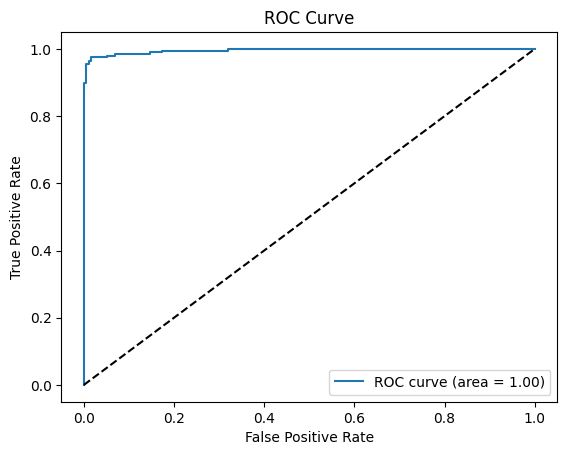

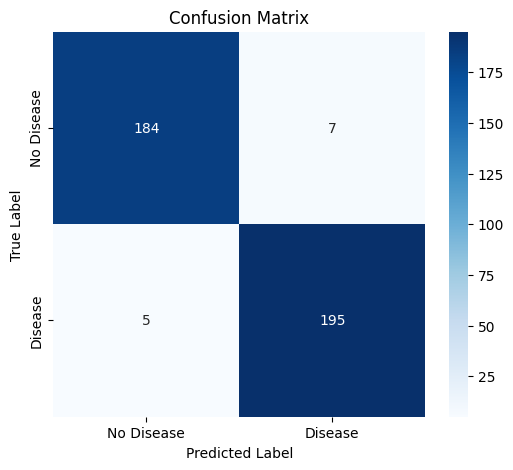

In [18]:
# -----------------
# Evaluation
# -----------------
cm = confusion_matrix(y_test, final_pred)
accuracy = accuracy_score(y_test, final_pred)
precision = precision_score(y_test, final_pred)
recall = recall_score(y_test, final_pred)
f1 = f1_score(y_test, final_pred)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, final_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()